# FEATURE DETECTION AND IMAGE MATCHING

In [1]:
import cv2
import matplotlib.pyplot as Phat


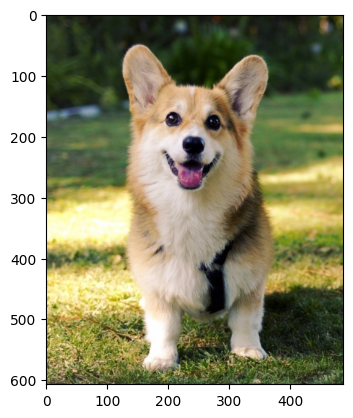

In [12]:
img = cv2.imread('dog.jpeg')
img = img[:,:,::-1]
Phat.imshow(img)

## 1. Thực hành xử lý ảnh trong miền tần số
- Fast Fourier Transform (FFT) algorithm để phát hiện ảnh mờ

In [3]:
# Để đọc ảnh và hiển thị ảnh, ta dùng matplotlib
import numpy as np
import cv2
from matplotlib import pyplot as Phat

In [13]:
# Đọc bức ảnh và đưa về float32
img = cv2.imread('dog.jpeg', 0)
img_float32 = img.astype('float32')

In [5]:
# Sau đó đưa ảnh về dạng số phức, và dùng fft có sẵn trong numpy để biến đổi để được biên độ của các sóng với các tần số khac
dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

In [6]:
# Đưa về thang log
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))

## 2. Sử dụng đoạn code sau cho DFT, trình bày ý nghĩa của từng dòng lệnh

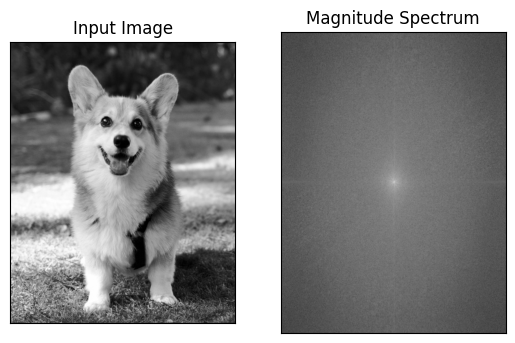

In [14]:
Phat.subplot(121), Phat.imshow(img, cmap='gray') # chia vùng ảnh thành 1 hàng 2 cột ở vị trí thứ 1, hiển thị ảnh img theo thang xám
Phat.title('Input Image'), Phat.xticks([]), Phat.yticks([]) # đặt tiêu đề cho ảnh, ẩn giá trị trục X và ẩn giá trị trục Y
Phat.subplot(122), Phat.imshow(magnitude_spectrum, cmap='gray') # chia vùng ảnh thành 1 hàng 2 cột ở vị trí thứ 2, hiển thị phổ biên độ của ảnh
Phat.title('Magnitude Spectrum'), Phat.xticks([]), Phat.yticks([]) # đặt tiêu đề cho ảnh, ẩn giá trị trục X và Y
Phat.show() # hiển thị ảnh

## 3. Sử dụng FFT Magnitude algorithm để phát hiện ảnh mờ

In [9]:
import numpy as np
import matplotlib.pyplot as Phat
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift

In [10]:
image = gravel()
wimage = image * window('hann', image.shape)
filterd_image = difference_of_gaussians(wimage, 1, 12)
filterd_wimage = filterd_image * window('hann', image.shape)
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filterd_wimage)))


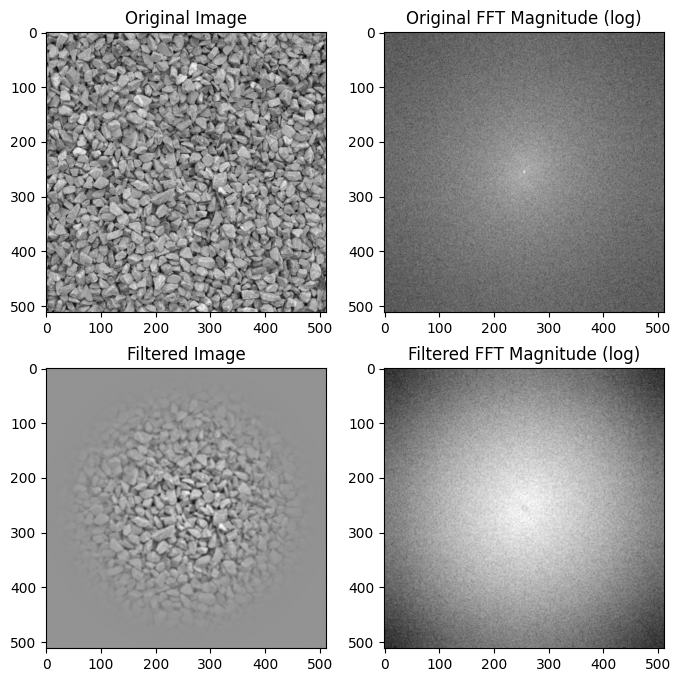

In [11]:
fig, ax = Phat.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='gray')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filterd_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='gray')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')
fig.show()

# THỰC HÀNH HARRIS CORNER DETECTION

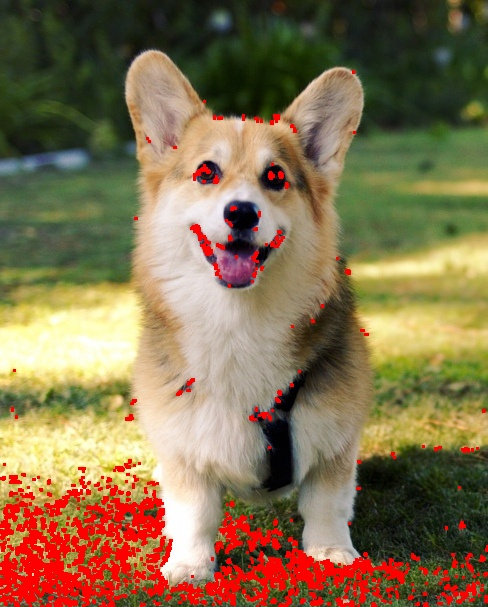

In [19]:
import cv2
import numpy as np
from IPython.display import Image
def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):
  img = cv2.imread(image_path)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  gray = np.float32(gray)
  dst = cv2.cornerHarris(gray, blockSize, ksize, k)

  dst = cv2.dilate(dst, None)

  img[dst>threshold*dst.max()]=[0, 0, 255]
  cv2.imwrite('example.jpg', img)
  return 'example.jpg'
out_path = detect_corner('dog.jpeg', blockSize=2, ksize=5, k=0.04, threshold=0.005)
Image(out_path)


In [20]:
# thử lại
import numpy as np
import cv2
from matplotlib import pyplot as Phat


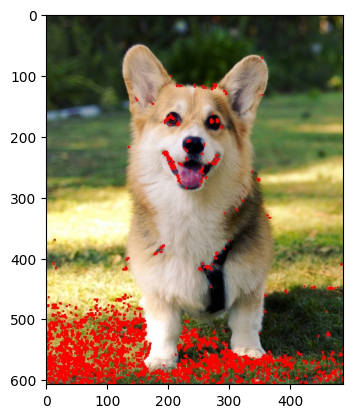

In [25]:
img = cv2.imread('example.jpg')
Phat.imshow(img[:,:,::-1])

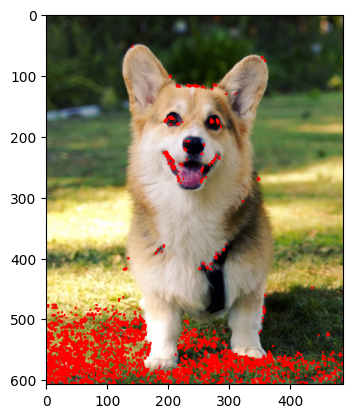

In [24]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)
dst = cv2.dilate(dst, None)
img[dst > 0.01 * dst.max()] = [0, 0, 255]
Phat.imshow(img[:,:,::-1])

# Band-pass filtering by Difference of Gaussians

In [26]:
import matplotlib.pyplot as Phat
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
import numpy as np
from scipy.fft import fftn, fftshift

In [27]:
image = gravel()
wimage = image*window('hann', image.shape)
filtered_image = difference_of_gaussians(wimage, 1, 12)
filtered_wimage = filtered_image*window('hann', image.shape)
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))

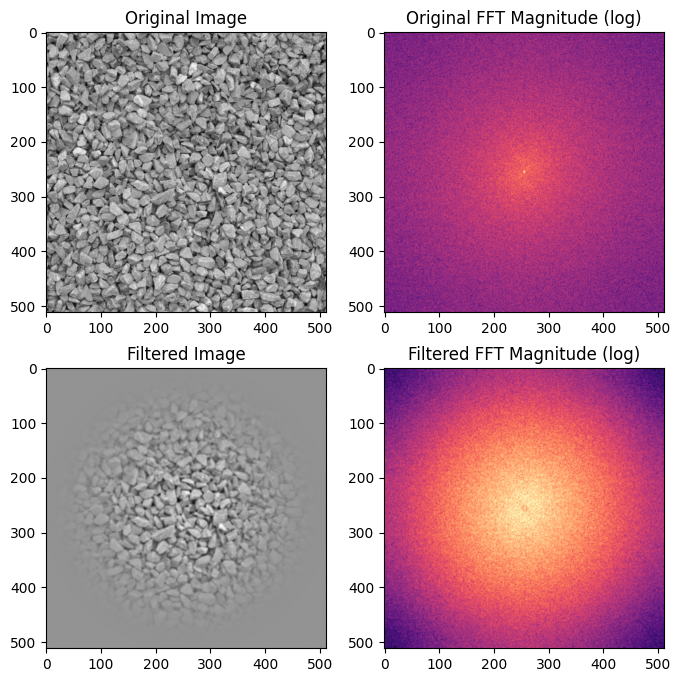

In [28]:
fig, ax = Phat.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')
Phat.show()